# AI4NTH Summer School Environment Check

Run this notebook after creating and activating the Conda environment. It checks that the software needed for the practical sessions is available on your laptop.

It verifies:
- Python version
- required package imports
- simple numerical and plotting functionality
- JupyterLab availability
- basic access to the course folders


## 1. Python and platform information

In [1]:
import sys, platform
from pathlib import Path

print('Python executable:', sys.executable)
print('Python version   :', platform.python_version())
print('Platform         :', platform.platform())
print('Machine          :', platform.machine())
print('Working directory:', Path.cwd())

assert sys.version_info >= (3, 11), 'Python 3.11 or newer is required.'
print('\nPASS: Python version is suitable.')

Python executable: /Users/wei.wang/miniforge/envs/ai4nth/bin/python
Python version   : 3.11.15
Platform         : macOS-26.5.1-arm64-arm-64bit
Machine          : arm64
Working directory: /Users/wei.wang/Work_RSDevelopment/GIT-EVENTS/AI4NTH-Summer-School/environment

PASS: Python version is suitable.


## 2. Required imports

In [2]:
import importlib

required = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'scipy': 'scipy',
    'matplotlib': 'matplotlib',
    'scikit-learn': 'sklearn',
    'joblib': 'joblib',
    'openpyxl': 'openpyxl',
    'pyyaml': 'yaml',
    'torch': 'torch',
    'jupyterlab': 'jupyterlab',
}

mods = {}
for label, module_name in required.items():
    mod = importlib.import_module(module_name)
    mods[module_name] = mod
    print(f"PASS: {label:12s} -> {getattr(mod, '__version__', 'unknown')}")

PASS: numpy        -> 2.4.6
PASS: pandas       -> 3.0.3
PASS: scipy        -> 1.17.1
PASS: matplotlib   -> 3.11.0
PASS: scikit-learn -> 1.9.0
PASS: joblib       -> 1.5.3
PASS: openpyxl     -> 3.1.5
PASS: pyyaml       -> 6.0.3
PASS: torch        -> 2.12.1
PASS: jupyterlab   -> 4.6.1


## 3. Bundle folder check

This cell tries to locate the summer school bundle root and check that the expected folders exist.

In [3]:
from pathlib import Path

here = Path.cwd().resolve()
candidates = [
    here,
    here.parent,
    here.parent.parent,
]

bundle_root = None
for cand in candidates:
    if (cand / 'course_materials').exists() or (cand / 'datasets').exists() or (cand / 'environment').exists():
        bundle_root = cand
        break

if bundle_root is None:
    bundle_root = here

print('Bundle root guess:', bundle_root)
for name in ['course_materials', 'datasets', 'environment']:
    path = bundle_root / name
    print(f"{'PASS' if path.exists() else 'WARN'}: {path}")


Bundle root guess: /Users/wei.wang/Work_RSDevelopment/GIT-EVENTS/AI4NTH-Summer-School
PASS: /Users/wei.wang/Work_RSDevelopment/GIT-EVENTS/AI4NTH-Summer-School/course_materials
PASS: /Users/wei.wang/Work_RSDevelopment/GIT-EVENTS/AI4NTH-Summer-School/datasets
PASS: /Users/wei.wang/Work_RSDevelopment/GIT-EVENTS/AI4NTH-Summer-School/environment


## 4. NumPy and pandas smoke test

In [4]:
import numpy as np
import pandas as pd

arr = np.array([[1.0, 2.0], [3.0, 4.0]])
df = pd.DataFrame(arr, columns=['a', 'b'])
display(df)
assert abs(df['a'].mean() - 2.0) < 1e-12
print('PASS: NumPy and pandas basic operations are working.')

,a,b
0,1.0,2.0
1,3.0,4.0


PASS: NumPy and pandas basic operations are working.


## 5. Matplotlib plot test

Matplotlib is building the font cache; this may take a moment.


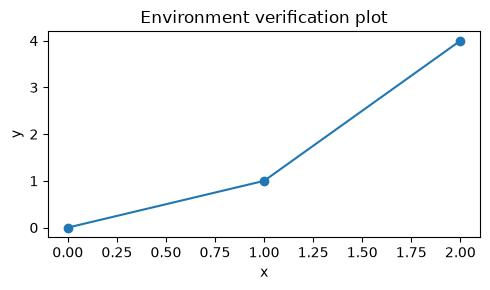

PASS: Matplotlib plotting works.


In [5]:
import matplotlib.pyplot as plt

x = [0, 1, 2]
y = [0, 1, 4]
plt.figure(figsize=(5, 3))
plt.plot(x, y, marker='o')
plt.title('Environment verification plot')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()
print('PASS: Matplotlib plotting works.')

## 6. scikit-learn smoke tests

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

X = np.linspace(0.0, 1.0, 20).reshape(-1, 1)
y = (X[:, 0] ** 2 + 0.1).astype(float)

lin = LinearRegression().fit(X, y)
lin_pred = lin.predict([[0.5]])[0]

rf = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=0, n_jobs=1).fit(X, y)
rf_pred = rf.predict([[0.5]])[0]

kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-4)
gp = GaussianProcessRegressor(kernel=kernel, random_state=0).fit(X, y)
gp_mean, gp_std = gp.predict([[0.5]], return_std=True)

print(f'PASS: LinearRegression prediction at x=0.5 -> {lin_pred:.6f}')
print(f'PASS: RandomForest prediction at x=0.5    -> {rf_pred:.6f}')
print(f'PASS: GP prediction mean/std at x=0.5     -> {gp_mean[0]:.6f}, {gp_std[0]:.6f}')

PASS: LinearRegression prediction at x=0.5 -> 0.442105
PASS: RandomForest prediction at x=0.5    -> 0.327147
PASS: GP prediction mean/std at x=0.5     -> 0.349551, 0.003429


/Users/wei.wang/miniforge/envs/ai4nth/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## 7. openpyxl write test

In [7]:
from openpyxl import Workbook
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    out = Path(tmpdir) / 'openpyxl_test.xlsx'
    wb = Workbook()
    ws = wb.active
    ws['A1'] = 'AI for NTH'
    ws['A2'] = 42
    wb.save(out)
    assert out.exists() and out.stat().st_size > 0

print('PASS: openpyxl workbook creation and save worked.')

PASS: openpyxl workbook creation and save worked.


## 8. PyTorch CPU smoke test

In [8]:
import torch
from torch import nn

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
model = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
with torch.no_grad():
    y = model(x)

print('PyTorch version:', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
print('Output shape   :', tuple(y.shape))
assert tuple(y.shape) == (2, 1)
print('PASS: PyTorch CPU test succeeded.')

PyTorch version: 2.12.1
CUDA available : False
Output shape   : (2, 1)
PASS: PyTorch CPU test succeeded.


## 9. JupyterLab availability

In [9]:
import subprocess

completed = subprocess.run(
    [sys.executable, '-m', 'jupyter', 'lab', '--version'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
    check=True,
)
version = completed.stdout.strip() or completed.stderr.strip() or 'unknown'
print('JupyterLab version:', version)
print('PASS: JupyterLab is available from the active environment.')

JupyterLab version: 4.6.1
PASS: JupyterLab is available from the active environment.


## 10. Final status

If all cells above have run successfully, the environment is ready for the summer school practical sessions.

**Next step:** move to the Day 1 materials.